# Slingshot Solver v2.4
## Gravitational Slingshot Dynamics in Restricted 3-Body Systems

Refactored modular implementation with:
- Unified Monte Carlo workflow (barycentric & planet-frame)
- Configuration-driven pipeline (YAML / Pydantic)
- Canonical km-kg-s unit system (constants from `slingshot.constants`)
- Robust trajectory analysis and encounter extraction
- Animation/video rendering support
- Parallelized particle evaluation
- **v2.3**: Star proximity filter, planet-frame diagnostics, energy extraction analysis
- **v2.4**: Unified pipeline, auto-generated REPORT.md, 14 diagnostic plots, cross-run comparison

**System**: Kepler-432 (K0V star, 1.19 M☉; hot Jupiter, 5.2 M♃, a ≈ 0.0896 AU)

## Setup and Configuration

In [22]:
%matplotlib inline
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path

# Add package to path
sys.path.insert(0, str(Path('.').resolve()))

import slingshot
from slingshot.config import load_config, FullConfig
from slingshot.constants import G_KM, M_SUN, M_JUP, R_JUP, R_SUN, AU_KM
from slingshot.monte_carlo import run_monte_carlo, select_top_indices
from slingshot.plotting import (
    plot_mc_summary, plot_best_candidate_with_bodies, plot_velocity_phase_space,
    plot_star_proximity_distribution, plot_planet_frame_diagnostics,
    plot_multi_candidate_overlay, plot_rejection_breakdown,
    plot_parameter_correlations, plot_energy_cdf,
)
from slingshot.animation import generate_all_animations
from slingshot.baselines import compare_3body_with_baselines
from slingshot.report import generate_run_report

print(f"Slingshot Solver v{slingshot.__version__}")
print(f"Unit system: km-kg-s  (energy: km²/s² ≡ MJ/kg)")
print(f"NumPy: {np.__version__}")

Slingshot Solver v2.4.0
Unit system: km-kg-s  (energy: km²/s² ≡ MJ/kg)
NumPy: 2.1.3


### Load Configuration

Choose between:
1. **Load from file** (recommended): YAML or JSON config
2. **Create in-place**: Python dict or FullConfig object
3. **Predefined system**: Quick setup by system name

In [23]:
import importlib
import slingshot.config
importlib.reload(slingshot.config)
from slingshot.config import load_config, FullConfig

# Option 1: Load from YAML file
cfg = load_config('configs/config_interstellar_k432.yaml')

# Option 2: Create configuration in Python
'''
from slingshot.config import (
    SystemConfig, SamplingConfig, NumericalConfig,
    PipelineConfig, FullConfig
)

cfg = FullConfig(
    system=SystemConfig(
        name="Kepler-432",
        M_star_Msun=1.19,
        R_star_Rsun=4.06,
        M_planet_Mjup=5.2,
        R_planet_Rjup=1.14,
        a_planet_AU=0.0896,
    ),
    sampling=SamplingConfig(
        mode="uniform",
        v_mag_min_kms=5.0,
        v_mag_max_kms=200.0,
        impact_param_min_AU=0.0001,
        impact_param_max_AU=0.005,
        angle_in_min_deg=-180.0,
        angle_in_max_deg=180.0,
        bary_unbound_requirement=True,
    ),
    numerical=NumericalConfig(
        rtol=1e-12,
        atol=1e-12,
        ode_method="DOP853",
        softening_km=100.0,
        r_far_factor=10.0,
        min_clearance_factor=2.0,
        flyby_r_min_max_hill=0.5,
        escape_radius_factor=5.0,
        star_min_clearance_Rstar=1.0,
    ),
    pipeline=PipelineConfig(
        N_particles=24000,
        n_parallel=8,
        t_mc_max_sec=5e8,
    ),
)
'''

print(f"Loaded configuration: {cfg.system.name}")
print(f"  Star:    {cfg.system.M_star_Msun:.2f} M☉ (R = {cfg.system.R_star_Rsun:.2f} R☉)")
print(f"  Planet:  {cfg.system.M_planet_Mjup:.1f} M♃ (R = {cfg.system.R_planet_Rjup:.2f} R♃)")
print(f"  Orbit:   {cfg.system.a_planet_AU:.4f} AU")
print(f"  MC Size: {cfg.pipeline.N_particles:,} particles")
print(f"  Star clearance filter: {cfg.numerical.star_min_clearance_Rstar} R★")

Loaded configuration: Kepler-432
  Star:    1.19 M☉ (R = 4.06 R☉)
  Planet:  5.2 M♃ (R = 1.16 R♃)
  Orbit:   0.0896 AU
  MC Size: 120 particles
  Star clearance filter: 2.0 R★


## Phase 1: Monte Carlo Sweep

Sample and integrate N test particles through encounters.

In [ ]:
# Derive physical quantities from config + canonical constants
m_star = cfg.system.M_star_Msun * M_SUN
m_p = cfg.system.M_planet_Mjup * M_JUP
R_p = cfg.system.R_planet_Rjup * R_JUP

print(f"Physical parameters (from slingshot.constants):")
print(f"  Star: {cfg.system.M_star_Msun:.2f} M☉  ({m_star:.3e} kg)")
print(f"  Planet: {cfg.system.M_planet_Mjup:.1f} M♃  (R={R_p:.0f} km)")
print(f"  Orbit: {cfg.system.a_planet_AU:.4f} AU")
print()

# Run Monte Carlo
print("Running Monte Carlo sweep …")
print(f"  Particles: {cfg.pipeline.N_particles}")
print(f"  Timespan: {cfg.pipeline.t_mc_max_sec:.1e} s")
print(f"  ODE method: {cfg.numerical.ode_method}")
print(f"  Softening: {cfg.numerical.softening_km:.1f} km")
if cfg.numerical.star_min_clearance_Rstar is not None:
    print(f"  Star filter: {cfg.numerical.star_min_clearance_Rstar:.1f} R★")

mc = run_monte_carlo(
    N=cfg.pipeline.N_particles,
    t_span=(0.0, cfg.pipeline.t_mc_max_sec),
    m_star=m_star,
    m_p=m_p,
    R_p=R_p,
    frame="barycentric",
    sampling_mode=cfg.sampling.mode,
    n_parallel=cfg.pipeline.n_parallel,
    verbose=True,
    v_mag_min=cfg.sampling.v_mag_min_kms,
    v_mag_max=cfg.sampling.v_mag_max_kms,
    impact_param_min_AU=cfg.sampling.impact_param_min_AU,
    impact_param_max_AU=cfg.sampling.impact_param_max_AU,
    angle_in_min_deg=cfg.sampling.angle_in_min_deg,
    angle_in_max_deg=cfg.sampling.angle_in_max_deg,
    r_init_AU=cfg.sampling.r_init_AU,
    rtol=cfg.numerical.rtol,
    atol=cfg.numerical.atol,
    r_far_factor=cfg.numerical.r_far_factor,
    min_clearance_factor=cfg.numerical.min_clearance_factor,
    bary_unbound_requirement=cfg.sampling.bary_unbound_requirement,
    flyby_r_min_max_hill=cfg.numerical.flyby_r_min_max_hill,
    escape_radius_factor=cfg.numerical.escape_radius_factor,
    ode_method=cfg.numerical.ode_method,
    softening_km=cfg.numerical.softening_km,
    # Star proximity filter (None = disabled for legacy configs)
    star_min_clearance_Rstar=cfg.numerical.star_min_clearance_Rstar,
    R_star_Rsun=cfg.system.R_star_Rsun,
)

ok_count = mc["ok"].sum()
print(f"\nResults: {ok_count}/{cfg.pipeline.N_particles} successful "
      f"({100.0*ok_count/cfg.pipeline.N_particles:.1f}%)")

# Show rejection breakdown
reasons = {}
for r in mc["results"]:
    if not r["ok"]:
        reasons[r["reason"]] = reasons.get(r["reason"], 0) + 1
if reasons:
    print(f"\nRejection breakdown:")
    for reason, count in sorted(reasons.items(), key=lambda x: -x[1]):
        print(f"  {reason}: {count}")

Physical parameters (from slingshot.constants):
  Star: 1.19 M☉  (2.366e+30 kg)
  Planet: 5.2 M♃  (R=82573 km)
  Orbit: 0.0896 AU

Running Monte Carlo sweep …
  Particles: 120
  Timespan: 5.0e+07 s
  ODE method: DOP853
  Softening: 1000.0 km
  Star filter: 2.0 R★
Monte Carlo: 120 particles, barycentric frame, barycentric sampling
  Hill sphere: 1496020 km (0.0100 AU)
  Flyby r_min threshold: 7480102 km (5.0 × r_Hill)
  Star filter: r_min_star > 2.0 R★ (5651520 km)
  Completed: 12/120
  Completed: 24/120


In [ ]:
# Create output directory for this run (used by all plot cells below)
from datetime import datetime

output_dir = Path(f"./results/results_{cfg.system.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}")
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {output_dir}")

# Track all saved plot paths for the report
saved_plots = []

# Derive physical constants used throughout
R_star_km = cfg.system.R_star_Rsun * R_SUN

Output directory: results\results_Kepler-432_20260209_202402


### MC Summary Visualization

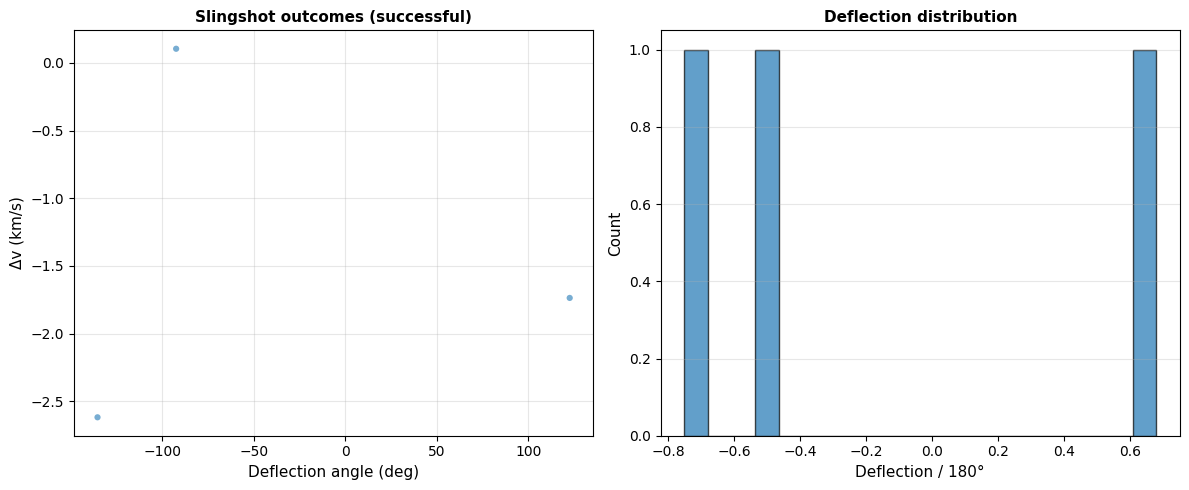

  Saved: mc_summary.png

Monte Carlo Summary Statistics:
  Δv range: [-2.62, 0.11] km/s
  Δv mean: -1.42 ± 1.13 km/s
  Deflection range: [-135.3, 122.6]°
  Deflection mean: -35.0 ± 112.8°


In [ ]:
fig = plot_mc_summary(mc, figsize=(12, 5))
fig.savefig(output_dir / "mc_summary.png", dpi=150, bbox_inches="tight")
saved_plots.append(str(output_dir / "mc_summary.png"))
display(fig)
plt.close(fig)
print(f"  Saved: mc_summary.png")

# Print statistics
delta_v_success = mc["delta_v"][mc["ok"]]
deflection_success = mc["deflection"][mc["ok"]]

print(f"\nMonte Carlo Summary Statistics:")
print(f"  Δv range: [{delta_v_success.min():.2f}, {delta_v_success.max():.2f}] km/s")
print(f"  Δv mean: {delta_v_success.mean():.2f} ± {delta_v_success.std():.2f} km/s")
print(f"  Deflection range: [{deflection_success.min():.1f}, {deflection_success.max():.1f}]°")
print(f"  Deflection mean: {deflection_success.mean():.1f} ± {deflection_success.std():.1f}°")

### MC Diagnostic Plots

Rejection breakdown, parameter correlations, star proximity distribution, and energy CDF.

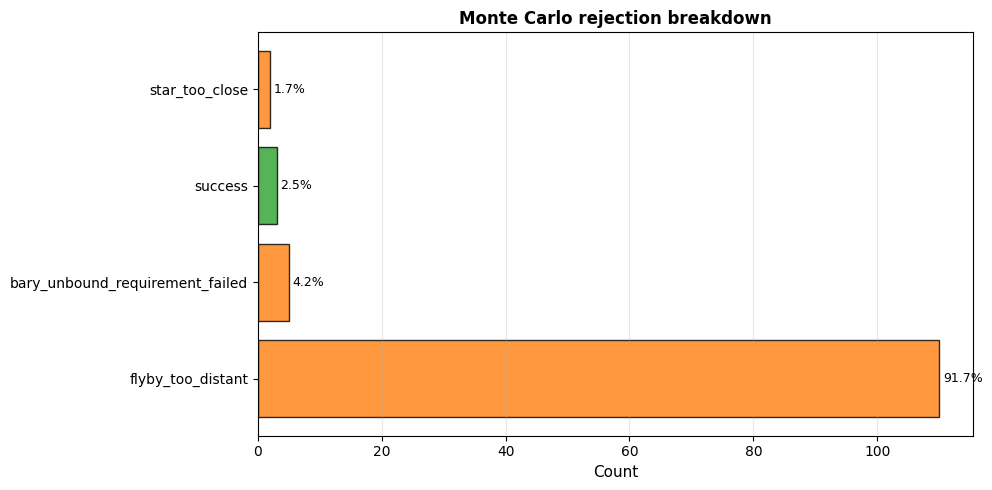

  Saved: rejection_breakdown.png


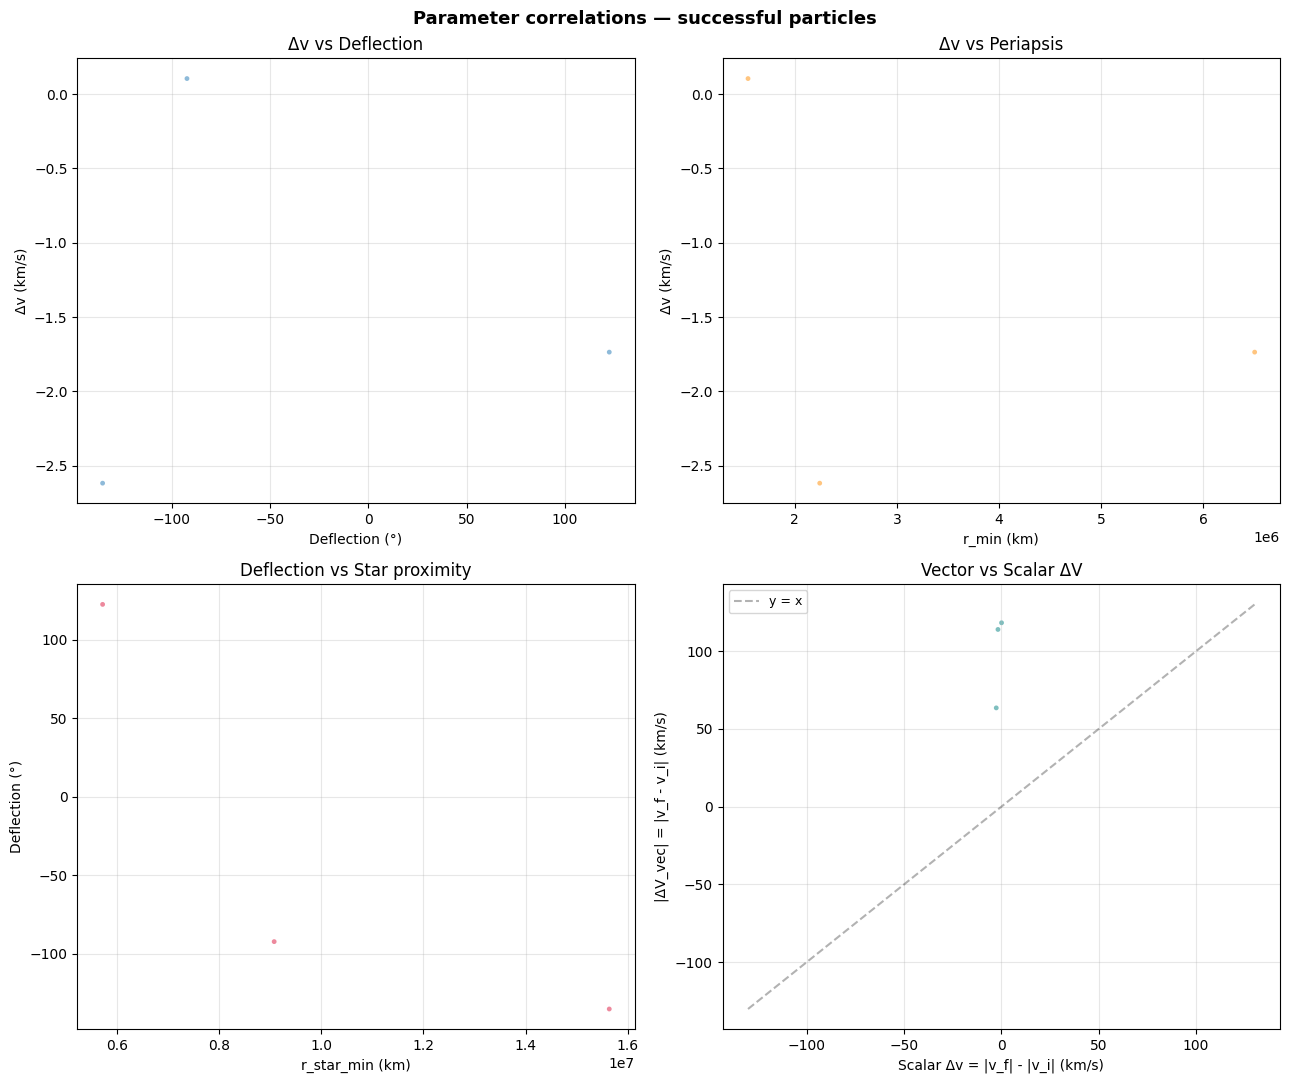

  Saved: parameter_correlations.png


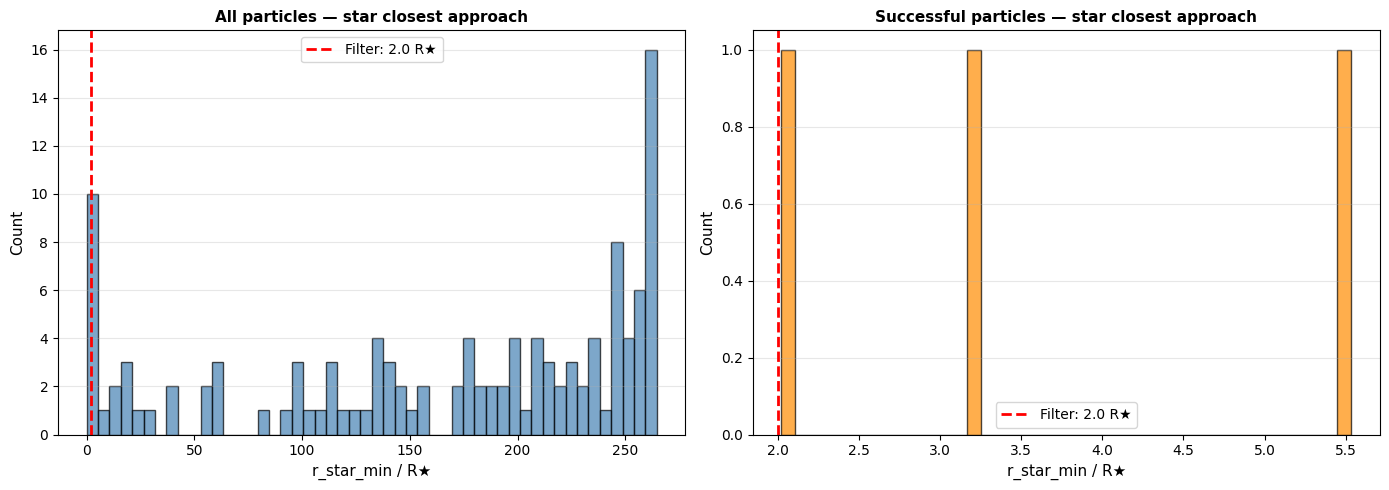

  Saved: star_proximity_distribution.png


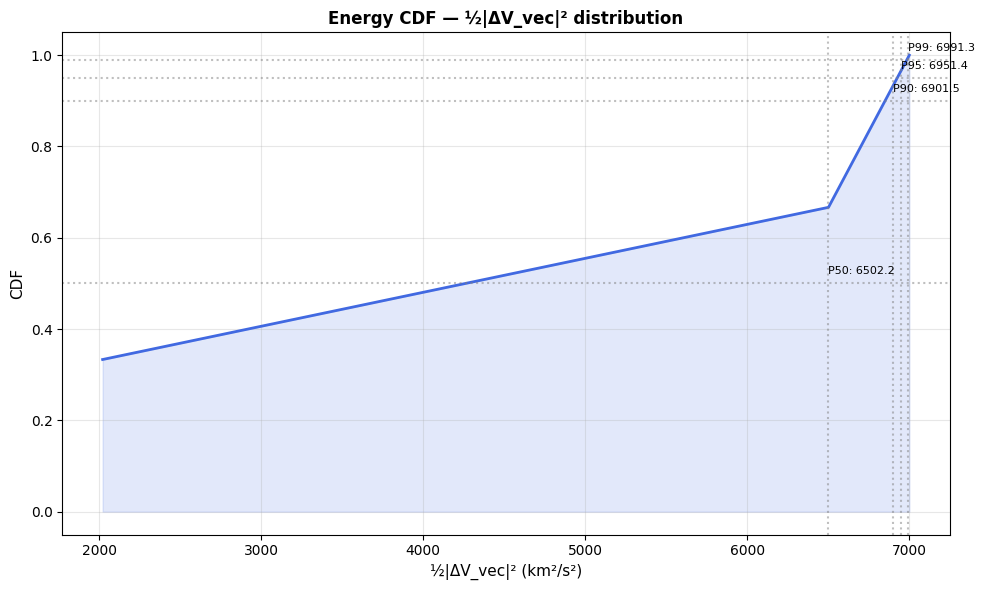

  Saved: energy_cdf_mc.png


In [ ]:
# Rejection breakdown
fig = plot_rejection_breakdown(mc, save_dir=None, dpi=150)
fig.savefig(output_dir / "rejection_breakdown.png", dpi=150, bbox_inches="tight")
saved_plots.append(str(output_dir / "rejection_breakdown.png"))
display(fig)
plt.close(fig)
print(f"  Saved: rejection_breakdown.png")

# Parameter correlations
fig = plot_parameter_correlations(mc, save_dir=None, dpi=150)
fig.savefig(output_dir / "parameter_correlations.png", dpi=150, bbox_inches="tight")
saved_plots.append(str(output_dir / "parameter_correlations.png"))
display(fig)
plt.close(fig)
print(f"  Saved: parameter_correlations.png")

# Star proximity distribution
star_clearance = cfg.numerical.star_min_clearance_Rstar
fig = plot_star_proximity_distribution(mc, R_star_km, clearance_Rstar=star_clearance, save_dir=None, dpi=150)
fig.savefig(output_dir / "star_proximity_distribution.png", dpi=150, bbox_inches="tight")
saved_plots.append(str(output_dir / "star_proximity_distribution.png"))
display(fig)
plt.close(fig)
print(f"  Saved: star_proximity_distribution.png")

# Energy CDF (MC-level)
fig = plot_energy_cdf(mc, save_dir=None, dpi=150)
fig.savefig(output_dir / "energy_cdf_mc.png", dpi=150, bbox_inches="tight")
saved_plots.append(str(output_dir / "energy_cdf_mc.png"))
display(fig)
plt.close(fig)
print(f"  Saved: energy_cdf_mc.png")

## Phase 2: Top Candidate Selection

In [ ]:
top_idx = select_top_indices(
    mc,
    top_frac=cfg.pipeline.top_frac,
    min_top=cfg.pipeline.min_top,
    metric="delta_v",
    sign=cfg.pipeline.select_sign,
)

print(f"Selected {len(top_idx)} top candidates (top {cfg.pipeline.top_frac*100:.0f}%)")
print(f"Indices: {top_idx}")

# Show top candidates
print("\nTop 5 candidates:")
for rank, idx in enumerate(top_idx[:5], 1):
    dv = mc["delta_v"][idx]
    defl = mc["deflection"][idx]
    print(f"  {rank}. MC#{idx}: Δv={dv:.2f} km/s, deflection={defl:.1f}°")

Selected 3 top candidates (top 10%)
Indices: [94 47  3]

Top 5 candidates:
  1. MC#94: Δv=0.11 km/s, deflection=-92.3°
  2. MC#47: Δv=-1.74 km/s, deflection=122.6°
  3. MC#3: Δv=-2.62 km/s, deflection=-135.3°


## Phase 3: High-Resolution Re-run

Re-integrate top candidates at higher resolution.

In [ ]:
import importlib
import slingshot.dynamics
importlib.reload(slingshot.dynamics)

from slingshot.dynamics import simulate_3body, init_hot_jupiter_barycentric
from slingshot.analysis import analyze_trajectory
from slingshot.constants import R_SUN

print(f"Re-running {len(top_idx)} candidates at high resolution...")
print(f"  Timespan: {cfg.pipeline.t_best_max_sec:.1e} s")
print(f"  Output points: {cfg.pipeline.n_eval_best}")
print(f"  Escape radius factor: {cfg.numerical.escape_radius_factor:.1f}×")
print(f"  ODE method: {cfg.numerical.ode_method}")
print(f"  Softening: {cfg.numerical.softening_km:.1f} km")

# Star filter for high-res candidates
R_star_km = cfg.system.R_star_Rsun * R_SUN
star_clearance_Rstar = cfg.numerical.star_min_clearance_Rstar
if star_clearance_Rstar is not None:
    star_clearance_km = star_clearance_Rstar * R_star_km
    print(f"  Star filter: r_min_star > {star_clearance_Rstar:.1f} R★ ({star_clearance_km:.0f} km)")
else:
    star_clearance_km = None

Y_sp0 = mc["Y_sp0"]
sat_states = mc["sat_states"]

sols_best = []
analyses_best = []
Y0_best = []
star_rejected = 0

for i, idx in enumerate(top_idx):
    if i % max(1, len(top_idx)//10) == 0:
        print(f"  Progress: {i+1}/{len(top_idx)}")
    
    # Reconstruct initial state
    xs, ys, vxs, vys, xp, yp, vxp, vyp = Y_sp0
    x3, y3, vx3, vy3 = sat_states[idx]
    Y0 = np.array([xs, ys, vxs, vys, xp, yp, vxp, vyp, x3, y3, vx3, vy3], dtype=float)
    
    # Escape radius: particle's initial barycentric distance × escape_radius_factor
    r0_bary = np.sqrt(x3**2 + y3**2)
    escape_r = r0_bary * cfg.numerical.escape_radius_factor
    
    # Integrate at high resolution (with terminal event for escape)
    sol = simulate_3body(
        Y0,
        (0.0, cfg.pipeline.t_best_max_sec),
        m_star=m_star,
        m_p=m_p,
        n_eval=cfg.pipeline.n_eval_best,
        rtol=cfg.numerical.rtol,
        atol=cfg.numerical.atol,
        escape_radius_km=escape_r,
        method=cfg.numerical.ode_method,
        softening_km=cfg.numerical.softening_km,
    )
    
    # Analyze
    ana = analyze_trajectory(
        sol,
        frame="barycentric",
        m_star=m_star,
        m_p=m_p,
        R_p=R_p,
        r_far_factor=cfg.numerical.r_far_factor,
        min_clearance_factor=cfg.numerical.min_clearance_factor,
    )
    
    # Post-hoc star filter on high-res candidates
    if ana is not None and star_clearance_km is not None:
        enc_hr = ana.get("encounter")
        if enc_hr is not None and enc_hr.r_star_min is not None:
            if enc_hr.r_star_min < star_clearance_km:
                ana = None  # Mark as invalid
                star_rejected += 1
    
    sols_best.append(sol)
    analyses_best.append(ana)
    Y0_best.append(Y0)

valid_count = sum(1 for a in analyses_best if a is not None)
print(f"Re-run complete: {valid_count}/{len(top_idx)} valid")
if star_rejected > 0:
    print(f"  Star-proximity rejected: {star_rejected}")

Re-running 3 candidates at high resolution...
  Timespan: 5.0e+07 s
  Output points: 0
  Escape radius factor: 3.0×
  ODE method: DOP853
  Softening: 1000.0 km
  Star filter: r_min_star > 2.0 R★ (5651520 km)
  Progress: 1/3
  Progress: 2/3
  Progress: 3/3
Re-run complete: 3/3 valid


## Phase 4: Detailed Analysis & Visualization

### Best Candidate Trajectory

In [ ]:
from slingshot.constants import R_SUN
R_star = cfg.system.R_star_Rsun * R_SUN

def _print_candidate(label, ana, orig_idx):
    enc = ana["encounter"]
    r_star_min_val = enc.r_star_min if enc and enc.r_star_min is not None else float('nan')
    print(f"{'='*60}")
    print(f"  {label}  (MC index #{orig_idx})")
    print(f"{'='*60}")
    print(f"  Δv (scalar):     {ana['delta_v']:>10.2f} km/s  ({ana['delta_v_pct']:+.1f}%)")
    print(f"  |ΔV_vec|:        {ana.get('delta_v_vec', float('nan')):>10.2f} km/s")
    print(f"  ½|ΔV_vec|²:      {ana.get('energy_half_dv_vec_sq', float('nan')):>10.2f} km²/s²")
    print(f"  Deflection:      {ana['deflection']:>10.1f}°  ({ana['deflection_frac']:.3f}×180)")
    print(f"  r_min (planet):  {ana['r_min']:>10.0f} km  ({ana['r_min']/R_p:.1f} R_p)")
    print(f"  r_min (star):    {r_star_min_val:>10.0f} km  ({r_star_min_val/R_star:.1f} R★)")
    print(f"  Impact param:    {ana['impact_parameter']:>10.0f} km")
    print(f"  Unbound (final): {str(ana['unbound_f']):>10s}")
    print(f"  ε_i:             {ana['eps_i']:>10.3e} km²/s²")
    print(f"  ε_f:             {ana['eps_f']:>10.3e} km²/s²")
    # Planet-frame diagnostics (energy extraction analysis)
    dvpf = ana.get('delta_v_planet_frame', None)
    if dvpf is not None:
        print(f"  --- Planet-frame diagnostics ---")
        print(f"  v_rel planet (in):  {ana.get('v_rel_planet_in', float('nan')):>8.2f} km/s")
        print(f"  v_rel planet (out): {ana.get('v_rel_planet_out', float('nan')):>8.2f} km/s")
        print(f"  Δv planet frame:    {dvpf:>8.2f} km/s  (0 = pure 2-body; ≠0 = star effect)")
        print(f"  Planet deflection:  {ana.get('planet_deflection_deg', float('nan')):>8.1f}°")
        efpo = ana.get('energy_from_planet_orbit', float('nan'))
        print(f"  ε from planet orbit: {efpo:>8.3e} km²/s²  (energy extracted from binary KE)")
        print(f"  Δε monopole:        {ana.get('delta_eps_monopole', float('nan')):>8.3e} km²/s²")

# --- Best by scalar Δv (speed change) — primary metric ---
valid_best = [(i, analyses_best[i]) for i in range(len(analyses_best)) if analyses_best[i] is not None]
if not valid_best:
    print("ERROR: No valid candidates after star filter!")
else:
    best_local_idx = max(valid_best, key=lambda x: x[1]["delta_v"])[0]
    best_sol = sols_best[best_local_idx]
    best_ana = analyses_best[best_local_idx]
    best_original_idx = top_idx[best_local_idx]
    
    _print_candidate("BEST by scalar Δv (|v_f| − |v_i|)", best_ana, best_original_idx)
    
    # --- Best by vector |ΔV_vec| (scattering energy) ---
    best_vec_local_idx = max(valid_best, key=lambda x: x[1].get("delta_v_vec", 0))[0]
    best_vec_sol = sols_best[best_vec_local_idx]
    best_vec_ana = analyses_best[best_vec_local_idx]
    best_vec_original_idx = top_idx[best_vec_local_idx]
    
    if best_vec_local_idx != best_local_idx:
        print()
        _print_candidate("BEST by |ΔV_vec| (scattering)", best_vec_ana, best_vec_original_idx)
    else:
        print(f"\n  (Same candidate is best by both metrics)")
    print("="*60)

  BEST by scalar Δv (|v_f| − |v_i|)  (MC index #94)
  Δv (scalar):           0.11 km/s  (+0.1%)
  |ΔV_vec|:            118.33 km/s
  ½|ΔV_vec|²:         7001.28 km²/s²
  Deflection:           -92.3°  (-0.513×180)
  r_min (planet):     1542835 km  (18.7 R_p)
  r_min (star):       9074405 km  (3.2 R★)
  Impact param:      22470944 km
  Unbound (final):       True
  ε_i:              3.148e+03 km²/s²
  ε_f:              3.298e+03 km²/s²
  --- Planet-frame diagnostics ---
  v_rel planet (in):     87.47 km/s
  v_rel planet (out):   180.89 km/s
  Δv planet frame:       93.42 km/s  (0 = pure 2-body; ≠0 = star effect)
  Planet deflection:       8.1°
  ε from planet orbit: 1.365e-04 km²/s²  (energy extracted from binary KE)
  Δε monopole:        1.499e+02 km²/s²

  (Same candidate is best by both metrics)


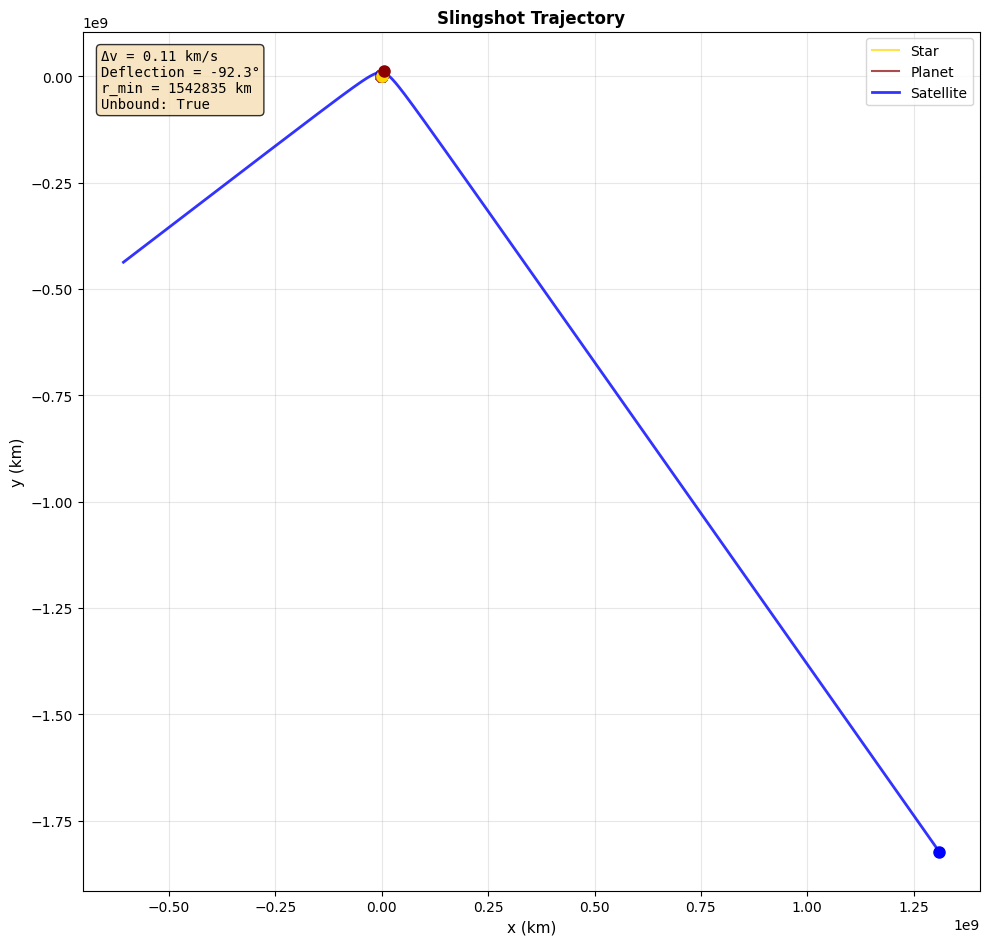

  Saved: best_candidate.png


In [ ]:
fig = plot_best_candidate_with_bodies(best_sol, best_ana, m_star=m_star, m_p=m_p, R_p=R_p)
fig.savefig(output_dir / "best_candidate.png", dpi=150, bbox_inches="tight")
saved_plots.append(str(output_dir / "best_candidate.png"))
display(fig)
plt.close(fig)
print(f"  Saved: best_candidate.png")

### Phase-Space Analysis

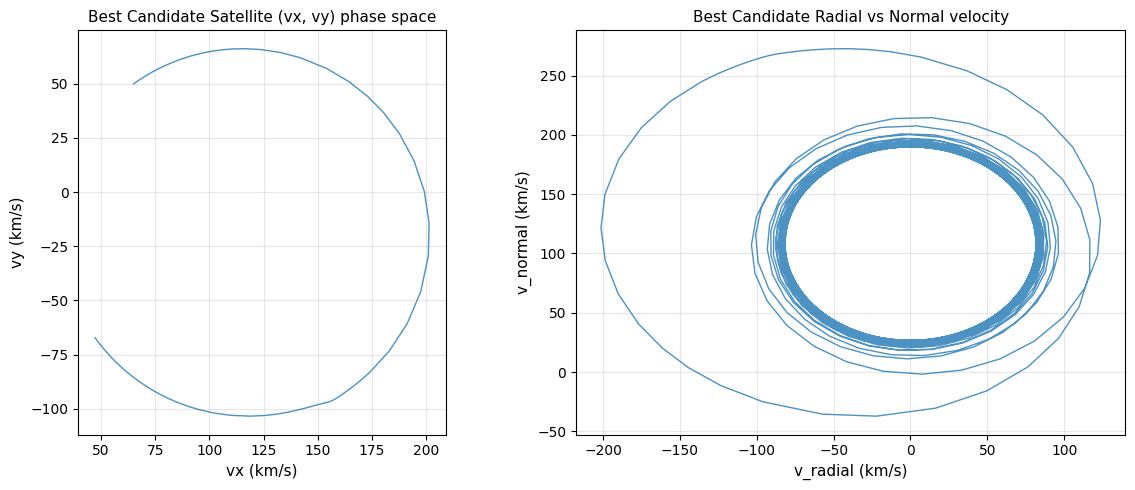

  Saved: velocity_phase_space.png


In [ ]:
fig = plot_velocity_phase_space(best_sol, title_prefix="Best Candidate", figsize=(12, 5))
fig.savefig(output_dir / "velocity_phase_space.png", dpi=150, bbox_inches="tight")
saved_plots.append(str(output_dir / "velocity_phase_space.png"))
display(fig)
plt.close(fig)
print(f"  Saved: velocity_phase_space.png")

### Candidate Diagnostic Plots

Planet-frame diagnostics and multi-candidate trajectory overlay.

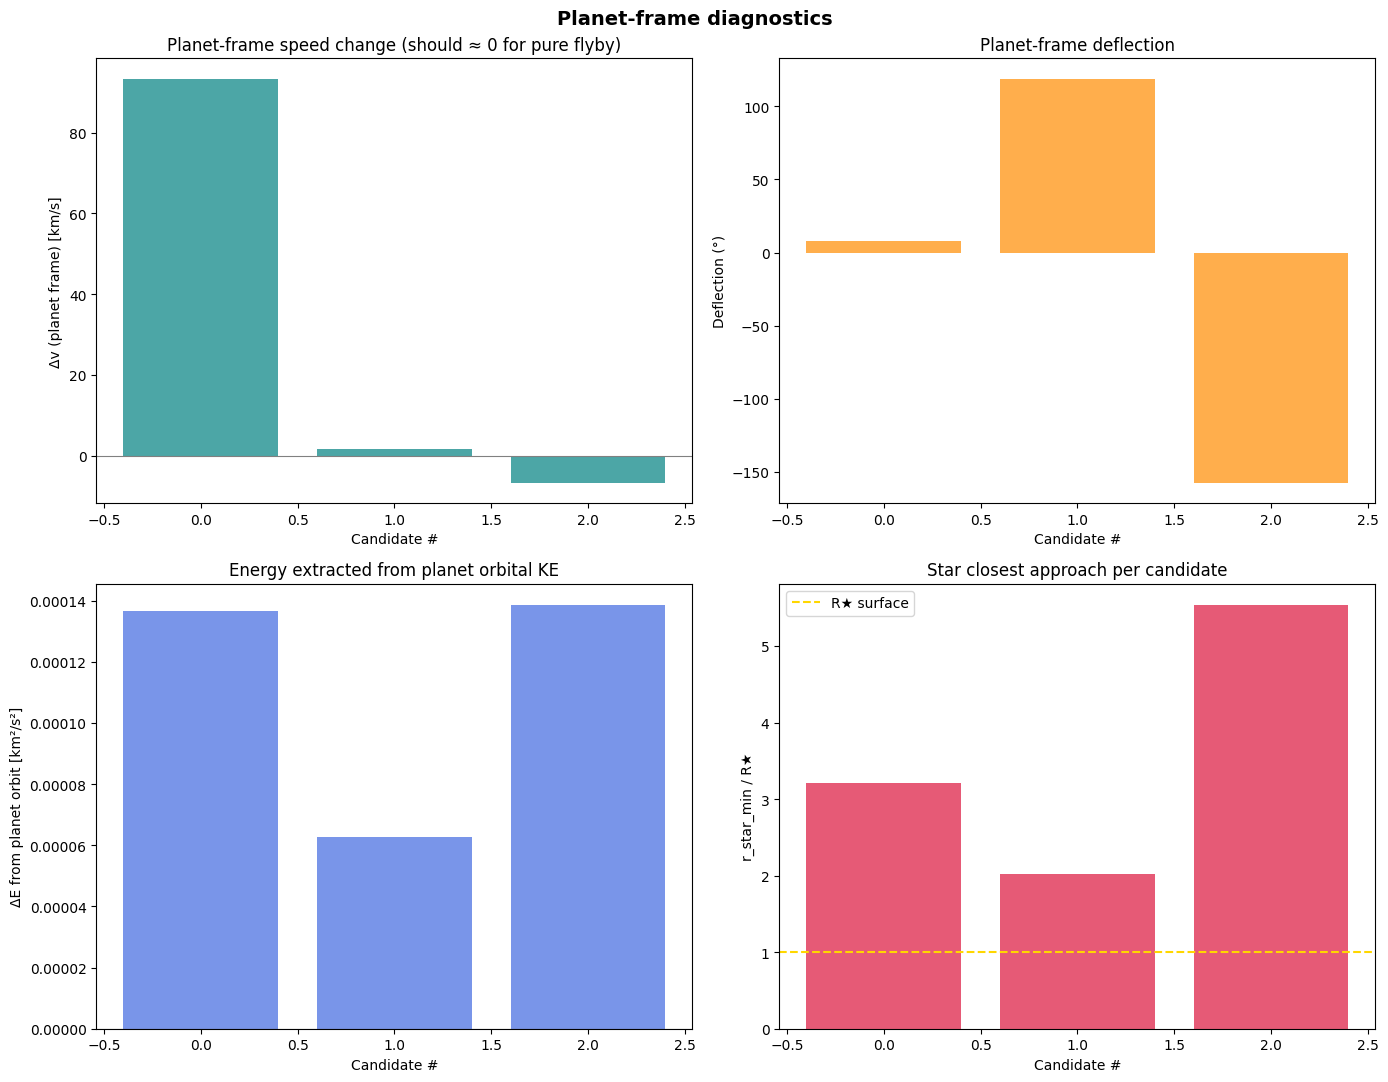

  Saved: planet_frame_diagnostics.png


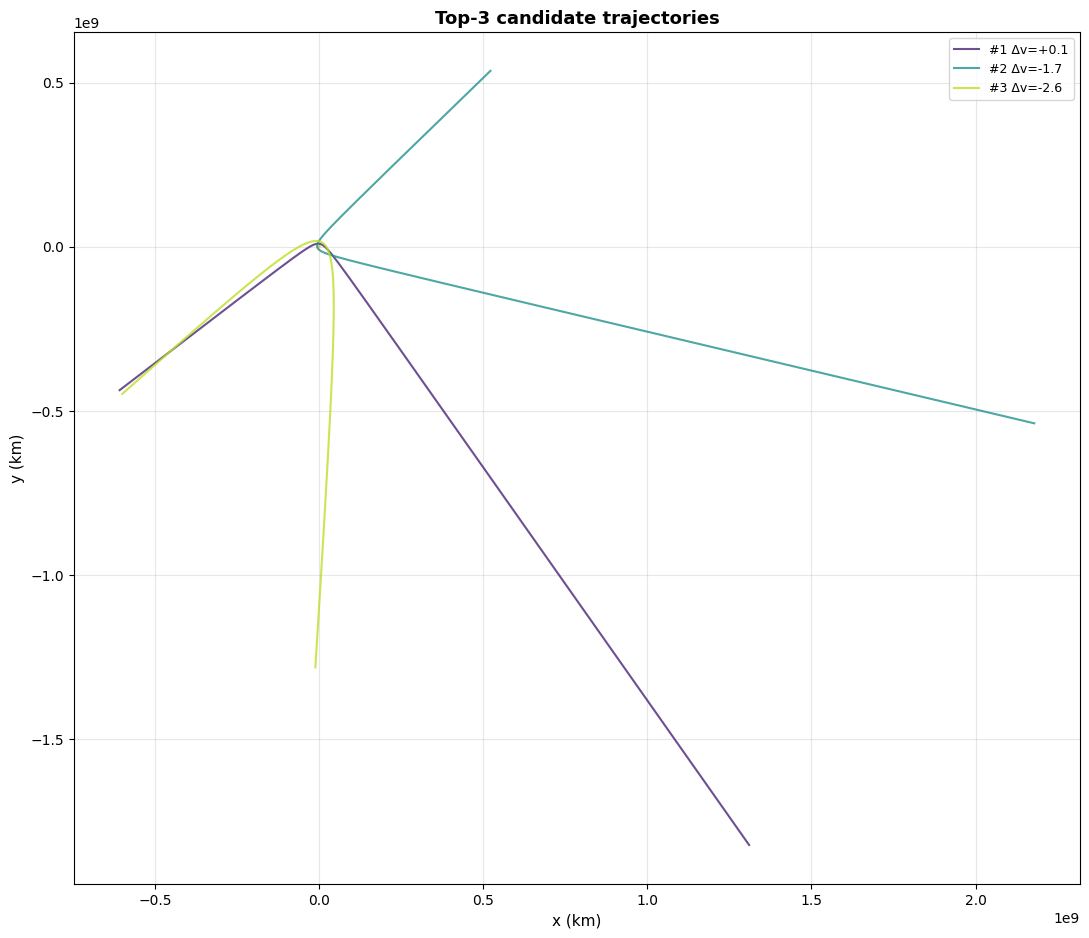

  Saved: multi_candidate_overlay.png (5 candidates)


In [ ]:
# Planet-frame diagnostics (4-panel bar charts)
valid_ana = [a for a in analyses_best if a is not None]
if valid_ana:
    fig = plot_planet_frame_diagnostics(valid_ana, R_p, R_star_km, save_dir=None, dpi=150)
    fig.savefig(output_dir / "planet_frame_diagnostics.png", dpi=150, bbox_inches="tight")
    saved_plots.append(str(output_dir / "planet_frame_diagnostics.png"))
    display(fig)
    plt.close(fig)
    print(f"  Saved: planet_frame_diagnostics.png")
else:
    print("  No valid analyses for planet-frame diagnostics")

# Multi-candidate overlay (top-N trajectories)
top_n = cfg.visualization.top_n_overlay
if sols_best:
    fig = plot_multi_candidate_overlay(
        sols_best, analyses_best,
        m_star=m_star, m_p=m_p,
        R_star=R_star_km, R_p=R_p,
        top_n=top_n, save_dir=None, dpi=150,
    )
    fig.savefig(output_dir / "multi_candidate_overlay.png", dpi=150, bbox_inches="tight")
    saved_plots.append(str(output_dir / "multi_candidate_overlay.png"))
    display(fig)
    plt.close(fig)
    print(f"  Saved: multi_candidate_overlay.png ({top_n} candidates)")
else:
    print("  No solutions for multi-candidate overlay")

### Baseline Comparison

Compare with 2-body hyperbola and monopole baselines.

In [ ]:
from slingshot.analysis import extract_encounter_states

# Extract encounter geometry
enc = extract_encounter_states(
    best_sol,
    m_p=m_p,
    R_p=R_p,
    r_far_factor=cfg.numerical.r_far_factor,
    min_clearance_factor=cfg.numerical.min_clearance_factor,
)

if enc.ok:
    # Compare with baselines
    comparison = compare_3body_with_baselines(
        best_sol,
        enc,
        m_star=m_star,
        m_p=m_p,
        R_p=R_p,
        make_plots=True,
        plot_save_dir=str(output_dir),
    )
    
    if comparison["ok"]:
        tb = comparison["two_body"]
        print(f"\nBaseline Comparison Results:")
        print(f"  2-body deflection (planet hyperbola): {tb['deflection_deg']:.1f}°")
        print(f"  3-body deflection (barycentric):      {comparison['deflection_3body']:.1f}°")
        print(f"  Extra Δε from planet presence:        {comparison['extra_eps_from_planet']:.3e} km²/s²")
        if tb['hyperbolic']:
            print(f"  2-body periapsis:  {tb['r_p']:.0f} km  ({tb['r_p']/R_p:.1f} R_p)")
            print(f"  2-body eccentricity:  {tb['e']:.2f}")
else:
    print(f"Encounter extraction failed: {enc.reason}")


Baseline Comparison Results:
  2-body deflection (planet hyperbola): 0.0°
  3-body deflection (barycentric):      92.3°
  Extra Δε from planet presence:        1.499e+02 km²/s²
  2-body periapsis:  739851373 km  (8959.9 R_p)
  2-body eccentricity:  8592.62


C:\Users\FoxtrotX146\OneDrive\GravResearch\slingshot-solver\slingshot\baselines.py:436: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\FoxtrotX146\OneDrive\GravResearch\slingshot-solver\slingshot\baselines.py:460: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Animation/Video Generation

Create animation frames for visual analysis.

In [ ]:
if cfg.visualization.render_video:
    print(f"Generating animations...")
    print(f"  Output dir: ./frames")
    print(f"  Format: {cfg.visualization.video_format}")
    print(f"  FPS: {cfg.visualization.video_fps}")
    
    animations = generate_all_animations(
        best_sol,
        output_dir="./frames",
        video_fps=cfg.visualization.video_fps,
        video_format=cfg.visualization.video_format,
        animate_trajectory=cfg.visualization.animate_trajectory,
        animate_phase_space=cfg.visualization.animate_phase_space,
    )
    
    for anim_type, filepath in animations.items():
        if filepath:
            print(f"  ✓ {anim_type}: {filepath}")
        else:
            print(f"  ✗ {anim_type}: Failed")
else:
    print("Video rendering disabled in config.")

Video rendering disabled in config.


## Exploratory Analysis: All Candidates

In [ ]:
# Create comparison table of all re-run candidates
candidates_table = []
for i, (idx, sol, ana) in enumerate(zip(top_idx, sols_best, analyses_best)):
    if ana:
        enc_i = ana.get("encounter")
        r_star_min_i = enc_i.r_star_min if enc_i and enc_i.r_star_min is not None else float('nan')
        candidates_table.append({
            'Rank': i+1,
            'MC_idx': idx,
            'Δv (km/s)': f"{ana['delta_v']:.2f}",
            'Δv (%)': f"{ana['delta_v_pct']:.1f}",
            'Deflection (°)': f"{ana['deflection']:.1f}",
            'r_min_planet (km)': f"{ana['r_min']:.0f}",
            'r_min_star (km)': f"{r_star_min_i:.0f}",
        })

import pandas as pd
df = pd.DataFrame(candidates_table)
print("\nTop Candidates Summary:")
print(df.to_string(index=False))


Top Candidates Summary:
 Rank  MC_idx Δv (km/s) Δv (%) Deflection (°) r_min_planet (km) r_min_star (km)
    1      94      0.11    0.1          -92.3           1542835         9074405
    2      47     -1.74   -2.6          122.6           6501350         5712717
    3       3     -2.62   -7.3         -135.3           2244572        15640570


## Save Configuration & Results

Store configuration and results for reproducibility.

In [ ]:
from slingshot.config import save_config
import pickle
import dataclasses

# output_dir was already created after the MC cell — reuse it
print(f"Saving to: {output_dir}")

# Save config
config_file = output_dir / "config.yaml"
save_config(cfg, str(config_file), format="yaml")
print(f"✓ Config saved: {config_file}")

# Deep-convert dataclass instances to plain dicts (avoids PicklingError after importlib.reload)
def _strip_dataclasses(obj):
    if dataclasses.is_dataclass(obj) and not isinstance(obj, type):
        return {k: _strip_dataclasses(v) for k, v in dataclasses.asdict(obj).items()}
    if isinstance(obj, dict):
        return {k: _strip_dataclasses(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_strip_dataclasses(v) for v in obj]
    return obj

# Save results
results_file = output_dir / "results.pkl"
with open(results_file, 'wb') as f:
    pickle.dump(_strip_dataclasses({
        'mc': mc,
        'top_indices': top_idx,
        'sols_best': sols_best,
        'analyses_best': analyses_best,
    }), f)
print(f"✓ Results saved: {results_file}")

# Save summary table
summary_file = output_dir / "summary.csv"
df.to_csv(summary_file, index=False)
print(f"✓ Summary saved: {summary_file}")

print(f"\nAll outputs in: {output_dir}")

Saving to: results\results_Kepler-432_20260209_202402
✓ Config saved: results\results_Kepler-432_20260209_202402\config.yaml
✓ Results saved: results\results_Kepler-432_20260209_202402\results.pkl
✓ Summary saved: results\results_Kepler-432_20260209_202402\summary.csv

All outputs in: results\results_Kepler-432_20260209_202402


## Phase 5: Cross-Solver Comparison — Narrowed Baselines (v2.2)

Run the closed-form 2-body baselines using **velocity-matched** parameter envelopes
derived from the top 3-body candidates.  This ensures the 2-body ceilings are computed
at the same approach speeds the 3-body solver actually explored, eliminating the
v_approach mismatch from v2.1.

**Pipeline:**
1. Extract encounter parameters (v_approach, b, angle, vstar0) from top 3-body analyses
2. Pad ranges by a configurable factor (default 1.5×)
3. Sweep TwoBodyScatter over the padded envelope for both star and planet scattering
4. Compare using **both** ε (specific orbital energy) and **|ΔV_vec|** (vector ΔV magnitude)

In [ ]:
# Reload slingshot modules (ensures latest code is picked up)
import importlib
import slingshot.config, slingshot.comparison, slingshot.analysis, slingshot.twobody
importlib.reload(slingshot.analysis)
importlib.reload(slingshot.twobody)
importlib.reload(slingshot.config)
importlib.reload(slingshot.comparison)

# Force reload narrowed_baselines (new module)
import slingshot.narrowed_baselines
importlib.reload(slingshot.narrowed_baselines)

from slingshot.narrowed_baselines import compute_narrowed_baselines, extract_envelope
from slingshot.comparison import compare_2body_3body, print_comparison

# --- Re-analyze top candidates with updated analysis.py ---
from slingshot.analysis import analyze_trajectory
from slingshot.constants import R_SUN

# Star filter threshold for re-analysis
R_star_km = cfg.system.R_star_Rsun * R_SUN
star_clearance_Rstar = cfg.numerical.star_min_clearance_Rstar
star_clearance_km = star_clearance_Rstar * R_star_km if star_clearance_Rstar is not None else None

analyses_best_v2 = []
star_filtered_v2 = 0
for sol in sols_best:
    ana_v2 = analyze_trajectory(
        sol, frame="barycentric",
        m_star=m_star, m_p=m_p, R_p=R_p,
        r_far_factor=cfg.numerical.r_far_factor,
        min_clearance_factor=cfg.numerical.min_clearance_factor,
    )
    # Apply star filter
    if ana_v2 is not None and star_clearance_km is not None:
        enc_v2_chk = ana_v2.get("encounter")
        if enc_v2_chk is not None and enc_v2_chk.r_star_min is not None:
            if enc_v2_chk.r_star_min < star_clearance_km:
                ana_v2 = None
                star_filtered_v2 += 1
    analyses_best_v2.append(ana_v2)

valid_count = sum(1 for a in analyses_best_v2 if a is not None)
print(f"Re-analyzed {len(sols_best)} top candidates → {valid_count} valid (v2.3 fields)")
if star_filtered_v2 > 0:
    print(f"  Star-proximity filtered: {star_filtered_v2}")

# Best by scalar Δv (primary metric for interstellar slingshot)
valid_v2 = [(i, a) for i, a in enumerate(analyses_best_v2) if a is not None]
if not valid_v2:
    print("ERROR: No valid candidates after filtering!")
    best_ana_v2 = None
    best_vec_ana_v2 = None
else:
    best_local_idx_v2 = max(valid_v2, key=lambda x: x[1]["delta_v"])[0]
    best_ana_v2 = analyses_best_v2[best_local_idx_v2]
    best_original_idx = top_idx[best_local_idx_v2]

    # Best by ½|ΔV_vec|² (scattering energy)
    best_vec_idx_v2 = max(valid_v2, key=lambda x: x[1]["energy_half_dv_vec_sq"])[0]
    best_vec_ana_v2 = analyses_best_v2[best_vec_idx_v2]

    print(f"\nBest by scalar Δv (MC#{best_original_idx}):")
    print(f"  delta_v (scalar |v_f|-|v_i|)  = {best_ana_v2['delta_v']:.4f} km/s")
    print(f"  delta_v_vec (|v_f - v_i|)     = {best_ana_v2['delta_v_vec']:.4f} km/s")
    print(f"  energy ½|ΔV_vec|²             = {best_ana_v2['energy_half_dv_vec_sq']:.4f} km²/s²")
    # Planet-frame diagnostics
    dvpf = best_ana_v2.get('delta_v_planet_frame', None)
    if dvpf is not None:
        print(f"  Δv planet frame               = {dvpf:.4f} km/s")
        print(f"  ε from planet orbit            = {best_ana_v2.get('energy_from_planet_orbit', float('nan')):.4e} km²/s²")

    print(f"\nBest by ½|ΔV_vec|² (MC#{top_idx[best_vec_idx_v2]}):")
    print(f"  delta_v (scalar |v_f|-|v_i|)  = {best_vec_ana_v2['delta_v']:.4f} km/s")
    print(f"  delta_v_vec (|v_f - v_i|)     = {best_vec_ana_v2['delta_v_vec']:.4f} km/s")
    print(f"  energy ½|ΔV_vec|²             = {best_vec_ana_v2['energy_half_dv_vec_sq']:.4f} km²/s²")
    print(f"  deflection                    = {best_vec_ana_v2['deflection']:.1f}°")
    enc_v2 = best_vec_ana_v2["encounter"]
    if enc_v2.star_v_bary_in is not None:
        print(f"  star v_bary at encounter      = {np.linalg.norm(enc_v2.star_v_bary_in):.4f} km/s")
    r_star_v2 = enc_v2.r_star_min if enc_v2 and enc_v2.r_star_min is not None else float('nan')
    print(f"  r_min (star)                  = {r_star_v2:.0f} km ({r_star_v2/R_star_km:.1f} R★)")

Re-analyzed 3 top candidates → 3 valid (v2.3 fields)

Best by scalar Δv (MC#94):
  delta_v (scalar |v_f|-|v_i|)  = 0.1051 km/s
  delta_v_vec (|v_f - v_i|)     = 118.3324 km/s
  energy ½|ΔV_vec|²             = 7001.2807 km²/s²
  Δv planet frame               = 93.4185 km/s
  ε from planet orbit            = 1.3651e-04 km²/s²

Best by ½|ΔV_vec|² (MC#94):
  delta_v (scalar |v_f|-|v_i|)  = 0.1051 km/s
  delta_v_vec (|v_f - v_i|)     = 118.3324 km/s
  energy ½|ΔV_vec|²             = 7001.2807 km²/s²
  deflection                    = -92.3°
  star v_bary at encounter      = 0.4518 km/s
  r_min (star)                  = 9074405 km (3.2 R★)


### Narrowed 2-Body Baselines (velocity-matched)

In [ ]:
# --- Compute narrowed baselines from top 3-body candidates ---
# Filter to valid analyses only
valid_analyses = [a for a in analyses_best_v2 if a is not None]

narrowed = compute_narrowed_baselines(
    analyses_top=valid_analyses,
    cfg=cfg,
    padding_factor=1.5,
    num_v=20,
    num_b=100,
    num_angles=100,
)

# Store results for CDF — use ½|ΔV_vec|² (body-dependent scattering energy)
# NOT max_epsilon which is ½v∞² (body-independent approach KE)
E_star_narrowed   = narrowed["star"].max_energy_half_dv_vec_sq   if narrowed["star"]   else None
E_planet_narrowed = narrowed["planet"].max_energy_half_dv_vec_sq if narrowed["planet"] else None
dv_vec_star  = narrowed["star"].max_deltaV_vec   if narrowed["star"]   else None
dv_vec_planet = narrowed["planet"].max_deltaV_vec if narrowed["planet"] else None

# 3-body best metrics — use best-by-½|ΔV_vec|² candidate (not best-by-scalar-Δv)
E_3body = best_vec_ana_v2["energy_half_dv_vec_sq"] if best_vec_ana_v2 else 0.0
dv_vec_3body = best_vec_ana_v2["delta_v_vec"] if best_vec_ana_v2 else 0.0

Envelope (3 candidates, padding=1.5x):
  v_approach : [69.02, 179.71] km/s
  b          : [1.06e+07, 7.42e+07] km
  angle      : [-123.3°, -25.7°]
  vstar0     : 0.45 km/s
[star] Narrowed sweep: 20×100×100 = 200000 encounters …
  40000/200000 (36300 valid) …
  80000/200000 (76200 valid) …
  120000/200000 (116200 valid) …
  160000/200000 (156200 valid) …
  200000/200000 (196200 valid) …
[star] Complete: 196200/200000 successful
[planet] Narrowed sweep: 20×100×100 = 200000 encounters …
  40000/200000 (40000 valid) …
  80000/200000 (80000 valid) …
  120000/200000 (120000 valid) …
  160000/200000 (160000 valid) …
  200000/200000 (200000 valid) …
[planet] Complete: 200000/200000 successful
  NARROWED BASELINE COMPARISON
  Parameter envelope derived from top 3-body candidates
Envelope (3 candidates, padding=1.5x):
  v_approach : [69.02, 179.71] km/s
  b          : [1.06e+07, 7.42e+07] km
  angle      : [-123.3°, -25.7°]
  vstar0     : 0.45 km/s
-----------------------------------------------

### Formal Comparison Table (ε + vector ΔV)

In [ ]:
# Build unified comparison dict with both metrics
# Uses best-by-½|ΔV_vec|² candidate for the 3-body column
comp = compare_2body_3body(
    # ε = ½v∞² (approach KE) — now correctly using max_epsilon, not ½|ΔV|²
    energy_2body_star=narrowed["star"].max_epsilon if narrowed["star"] else None,
    energy_2body_planet=narrowed["planet"].max_epsilon if narrowed["planet"] else None,
    energy_3body=E_3body,
    # Scalar ΔV baselines (best achievable |v_f| - |v_i| from 2-body sweeps)
    dv_2body_star=dv_vec_star,    # star vector ΔV as upper bound
    dv_2body_planet=dv_vec_planet, # planet vector ΔV as upper bound
    dv_3body=best_vec_ana_v2["delta_v"] if best_vec_ana_v2 else None,
    # Vector ΔV
    dv_vec_2body_star=dv_vec_star,
    dv_vec_2body_planet=dv_vec_planet,
    dv_vec_3body=dv_vec_3body,
    envelope_summary=narrowed["envelope"].summary() if narrowed["envelope"] else None,
    baseline_mode="narrowed",
)
print_comparison(comp)

  2-BODY  vs  3-BODY  COMPARISON
  All energies in km²/s² ≡ MJ/kg

--- ½|ΔV_vec|²  (scattering energy, body-dependent) ---
  Star  2-body max ½|ΔV|²  : 14939.47 km²/s² (14939.47 MJ/kg)
  Planet 2-body max ½|ΔV|² : 1.6295 km²/s² (1.6295 MJ/kg)
  3-body best ½|ΔV|²       : 7001.28 km²/s² (7001.28 MJ/kg)

--- ε = ½v∞²  (approach KE — same for any body at same speed) ---
  Star  baseline ε  : 16145.67 km²/s² (16145.67 MJ/kg)
  Planet baseline ε : 16147.24 km²/s² (16147.24 MJ/kg)
  3-body best ε     : 7001.28 km²/s² (7001.28 MJ/kg)
------------------------------------------------------------

  ΔV scalar (3-body best) : 0.11 km/s
  ΔV improvement (planet)  : -1.70 km/s
  ΔV improvement (star)    : -172.75 km/s

--- Scalar ΔV (|v_f| - |v_i|) ---
  Star  2-body max scalar ΔV    : 172.86 km/s
  Planet 2-body max scalar ΔV   : 1.81 km/s
  3-body best scalar ΔV         : 0.11 km/s

--- Vector ΔV (|v_f - v_i|) ---
  Star  2-body max |ΔV_vec|  : 172.86 km/s
  Planet 2-body max |ΔV_vec| : 1.81 km/s

### Energy CDF Overlay — Narrowed Baselines

Cumulative distribution of 3-body MC energies (½|ΔV_vec|²) against the
velocity-matched 2-body upper bounds.

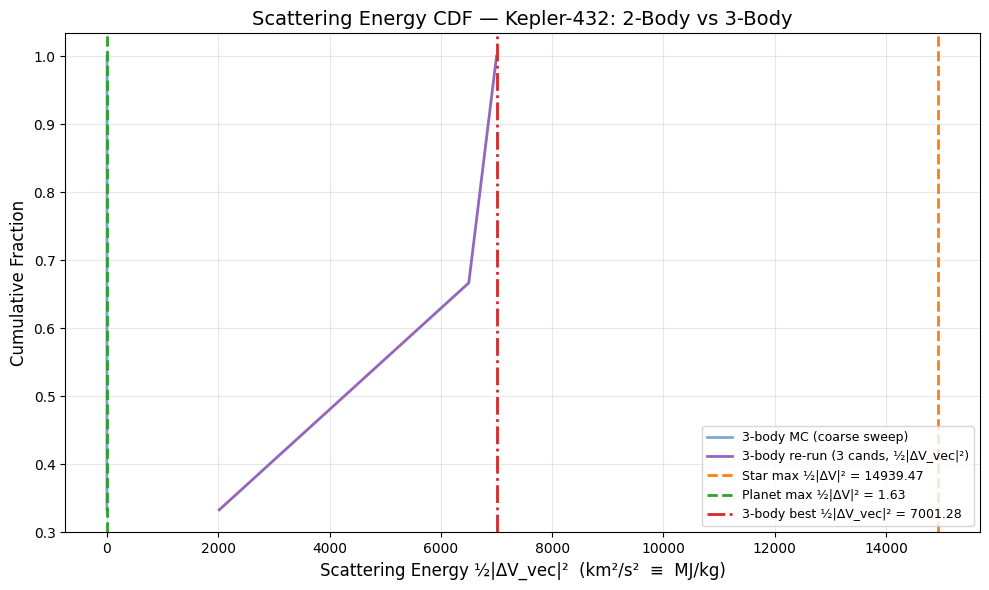

  Saved: energy_cdf.png

Coarse MC sweep (3 particles):
  Exceeding star  ½|ΔV|² bound: 0.0%
  Exceeding planet ½|ΔV|² bound: 33.3%

High-res re-runs (3 candidates, ½|ΔV_vec|²):
  Exceeding star  ½|ΔV|² bound: 0/3 (0.0%)
  Exceeding planet ½|ΔV|² bound: 3/3 (100.0%)


In [ ]:
# --- Energy CDF: 3-body MC vs narrowed 2-body baselines ---

# Coarse MC energies (using vector ΔV for consistency)
ok = mc["ok"]
# Re-compute with vector magnitude: for coarse MC we only have scalar delta_v
# Use ½ delta_v² as approximate energy (coarse only)
energies_mc_coarse = 0.5 * mc["delta_v"][ok] ** 2

# Re-run energies using the new vector ΔV metric
energies_rerun = np.array([
    a["energy_half_dv_vec_sq"] for a in analyses_best_v2 if a is not None
])

fig, ax = plt.subplots(figsize=(10, 6))

# 3-body CDF (coarse MC)
sorted_e = np.sort(energies_mc_coarse)
cdf = np.arange(1, len(sorted_e) + 1) / len(sorted_e)
ax.plot(sorted_e, cdf, linewidth=2, label="3-body MC (coarse sweep)", color="tab:blue", alpha=0.6)

# 3-body CDF (high-res re-runs, vector ΔV)
if len(energies_rerun) > 1:
    sorted_er = np.sort(energies_rerun)
    cdf_r = np.arange(1, len(sorted_er) + 1) / len(sorted_er)
    ax.plot(sorted_er, cdf_r, linewidth=2,
            label=f"3-body re-run ({len(energies_rerun)} cands, ½|ΔV_vec|²)",
            color="tab:purple", linestyle="-")

# Narrowed 2-body star baseline (now ½|ΔV_vec|², not ε)
if E_star_narrowed is not None:
    ax.axvline(E_star_narrowed, color="tab:orange", linestyle="--", linewidth=2,
               label=f"Star max ½|ΔV|² = {E_star_narrowed:.2f}")

# Narrowed 2-body planet baseline (now ½|ΔV_vec|², not ε)
if E_planet_narrowed is not None:
    ax.axvline(E_planet_narrowed, color="tab:green", linestyle="--", linewidth=2,
               label=f"Planet max ½|ΔV|² = {E_planet_narrowed:.2f}")

# 3-body best (vector ΔV energy)
ax.axvline(E_3body, color="tab:red", linestyle="-.", linewidth=2,
           label=f"3-body best ½|ΔV_vec|² = {E_3body:.2f}")

ax.set_xlabel("Scattering Energy ½|ΔV_vec|²  (km²/s²  ≡  MJ/kg)", fontsize=12)
ax.set_ylabel("Cumulative Fraction", fontsize=12)
ax.set_title(f"Scattering Energy CDF — {cfg.system.name}: 2-Body vs 3-Body", fontsize=14)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(output_dir / "energy_cdf.png", dpi=150, bbox_inches="tight")
saved_plots.append(str(output_dir / "energy_cdf.png"))
display(fig)
plt.close(fig)
print(f"  Saved: energy_cdf.png")

# Summary statistics
print(f"\nCoarse MC sweep ({len(energies_mc_coarse)} particles):")
if E_star_narrowed is not None:
    frac_above_star = (energies_mc_coarse > E_star_narrowed).sum() / len(energies_mc_coarse) * 100
    print(f"  Exceeding star  ½|ΔV|² bound: {frac_above_star:.1f}%")
if E_planet_narrowed is not None:
    frac_above_planet = (energies_mc_coarse > E_planet_narrowed).sum() / len(energies_mc_coarse) * 100
    print(f"  Exceeding planet ½|ΔV|² bound: {frac_above_planet:.1f}%")

print(f"\nHigh-res re-runs ({len(energies_rerun)} candidates, ½|ΔV_vec|²):")
if E_star_narrowed is not None:
    n_above = (energies_rerun > E_star_narrowed).sum()
    print(f"  Exceeding star  ½|ΔV|² bound: {n_above}/{len(energies_rerun)} "
          f"({n_above/len(energies_rerun)*100:.1f}%)")
if E_planet_narrowed is not None:
    n_above = (energies_rerun > E_planet_narrowed).sum()
    print(f"  Exceeding planet ½|ΔV|² bound: {n_above}/{len(energies_rerun)} "
          f"({n_above/len(energies_rerun)*100:.1f}%)")

## Generate Report

Auto-generate `REPORT.md` with system parameters, MC statistics, best candidates,
2-body vs 3-body comparison, and all saved plot references — matching the CLI pipeline output.

In [ ]:
# Build the 'best' dict matching the pipeline convention
best_dict = {
    "best_ana": best_ana,
    "best_sol": best_sol,
    "best_idx": int(best_original_idx),
    "best_vec_ana": best_vec_ana,
    "best_vec_sol": best_vec_sol,
    "best_vec_idx": int(best_vec_original_idx),
}

report_text = generate_run_report(
    output_dir=output_dir,
    cfg=cfg,
    mc=mc,
    analyses_best=analyses_best,
    best=best_dict,
    comparison=comp if 'comp' in dir() else None,
    narrowed=narrowed if 'narrowed' in dir() else None,
    saved_plots=saved_plots,
)
print(f"✓ Report saved: {output_dir / 'REPORT.md'}")
print(f"  ({len(saved_plots)} plots referenced)")

✓ Report saved: results\results_Kepler-432_20260209_202402\REPORT.md
  (10 plots referenced)
